# Task 3 – Using the CLI tool with Jupyter

Goal: find the **overall most abundant complaint type** in the first two months of 2024 (Jan 1 – Feb 29), plot its number of occurrences (per borough), and compare it with the same complaint type in June–July 2024.

All counting is done by `borough_complaints.py` (Task 1); the notebook only reads its small CSV output.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

# trimmed 2024 dataset (see trim_2024.sh); override with the NYC311_2024 env var
DATA = os.environ.get('NYC311_2024', os.path.expanduser('~/hw5_data/nyc_311_2024.csv'))
PY = sys.executable
print(DATA, os.path.getsize(DATA) // 2**20, 'MB')

C:\Users\HP-ENVY/hw5_data/nyc_311_2024.csv 1970 MB


In [2]:
!"{PY}" borough_complaints.py -h

usage: borough_complaints.py [-h] -i INPUT_CSV -s START_DATE -e END_DATE
                             [-o OUTPUT_CSV]

Output the number of each complaint type per borough for incidents created
within a given date range (inclusive), as CSV: complaint type, borough, count.

options:
  -h, --help            show this help message and exit
  -i INPUT_CSV, --input INPUT_CSV
                        the input NYC 311 csv file
  -s START_DATE, --start START_DATE
                        first creation date to include (YYYY-MM-DD or
                        MM/DD/YYYY)
  -e END_DATE, --end END_DATE
                        last creation date to include (YYYY-MM-DD or
                        MM/DD/YYYY)
  -o OUTPUT_CSV, --output OUTPUT_CSV
                        write results to this file instead of stdout

example: borough_complaints.py -i nyc_311_2024.csv -s 2024-01-01 -e 2024-02-29
-o out.csv


## Run the CLI tool for both periods

In [3]:
%%time
!"{PY}" borough_complaints.py -i "{DATA}" -s 2024-01-01 -e 2024-02-29 -o jan_feb_2024.csv
!"{PY}" borough_complaints.py -i "{DATA}" -s 2024-06-01 -e 2024-07-31 -o jun_jul_2024.csv

CPU times: total: 531 ms
Wall time: 1min 45s


In [4]:
jan_feb = pd.read_csv('jan_feb_2024.csv')
jun_jul = pd.read_csv('jun_jul_2024.csv')
jan_feb.head()

,complaint type,borough,count
0,Abandoned Bike,Bronx,8
1,Abandoned Bike,Brooklyn,172
2,Abandoned Bike,Manhattan,98
3,Abandoned Bike,Queens,39
4,Abandoned Bike,Staten Island,2


## Which complaint type is the most abundant in Jan–Feb 2024?
Sum the per-borough counts to get citywide totals per complaint type.

In [5]:
totals_jf = jan_feb.groupby('complaint type')['count'].sum().sort_values(ascending=False)
top_type = totals_jf.index[0]
print('Most abundant complaint type in Jan-Feb 2024:', repr(top_type))
(totals_jf.head(10).to_frame('Jan-Feb count')
 .assign(share=lambda d: (100 * d['Jan-Feb count'] / totals_jf.sum()).round(1).astype(str) + '%'))

Most abundant complaint type in Jan-Feb 2024: 'HEAT/HOT WATER'


,Jan-Feb count,share
complaint type,,
HEAT/HOT WATER,81631,15.6%
Illegal Parking,79916,15.3%
Noise - Residential,43601,8.4%
Blocked Driveway,28608,5.5%
UNSANITARY CONDITION,19206,3.7%
PLUMBING,12057,2.3%
PAINT/PLASTER,11725,2.2%
Abandoned Vehicle,11452,2.2%
Street Condition,10741,2.1%


In [6]:
totals_jj = jun_jul.groupby('complaint type')['count'].sum().sort_values(ascending=False)
print('Rank of', repr(top_type), 'in Jun-Jul 2024:', list(totals_jj.index).index(top_type) + 1)
totals_jj.head(10).to_frame('Jun-Jul count')

Rank of 'HEAT/HOT WATER' in Jun-Jul 2024: 25


,Jun-Jul count
complaint type,
Illegal Parking,86237
Noise - Residential,58196
Noise - Street/Sidewalk,47318
Blocked Driveway,27193
Water System,21637
UNSANITARY CONDITION,21575
Street Condition,13155
Dirty Condition,12398
Abandoned Vehicle,12214


## Bar chart: occurrences of the top complaint type, Jan–Feb 2024

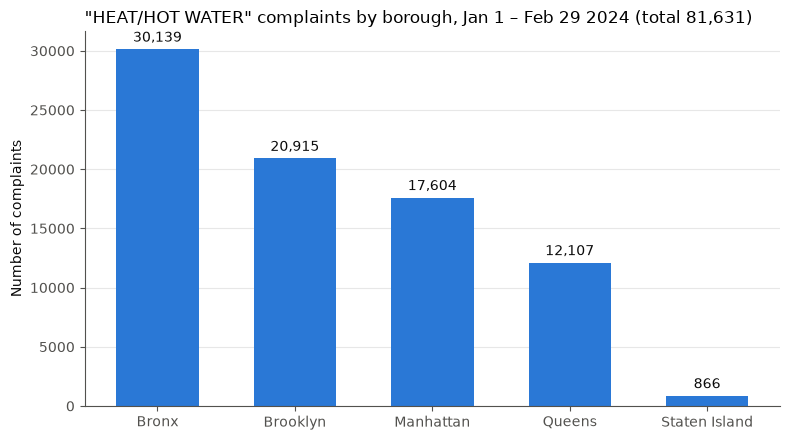

In [7]:
BLUE, ORANGE, INK, MUTED = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': MUTED, 'axes.labelcolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})

def by_borough(df):
    return df[df['complaint type'] == top_type].set_index('borough')['count']

jf = by_borough(jan_feb).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(jf.index, jf.values, color=BLUE, width=0.6)
ax.bar_label(bars, labels=[f'{v:,}' for v in jf.values], padding=3, color=INK)
ax.set_title(f'"{top_type}" complaints by borough, Jan 1 – Feb 29 2024 (total {jf.sum():,})', loc='left')
ax.set_ylabel('Number of complaints')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig('top_complaint_jan_feb_2024.png', dpi=120); plt.show()

## Comparison with June–July 2024
Jan–Feb 2024 has 60 days and Jun–Jul has 61, so we also compare the daily rate.

In [8]:
cmp = pd.DataFrame({'Jan-Feb 2024': by_borough(jan_feb), 'Jun-Jul 2024': by_borough(jun_jul)}).fillna(0).astype(int)
cmp = cmp.sort_values('Jan-Feb 2024', ascending=False)
cmp.loc['ALL BOROUGHS'] = cmp.sum()
cmp['per day (Jan-Feb)'] = (cmp['Jan-Feb 2024'] / 60).round(1)
cmp['per day (Jun-Jul)'] = (cmp['Jun-Jul 2024'] / 61).round(1)
cmp['change'] = ((cmp['Jun-Jul 2024'] / cmp['Jan-Feb 2024'] - 1) * 100).round(1).astype(str) + '%'
cmp

,Jan-Feb 2024,Jun-Jul 2024,per day (Jan-Feb),per day (Jun-Jul),change
borough,,,,,
Bronx,30139,2227,502.3,36.5,-92.6%
Brooklyn,20915,1929,348.6,31.6,-90.8%
Manhattan,17604,1777,293.4,29.1,-89.9%
Queens,12107,835,201.8,13.7,-93.1%
Staten Island,866,121,14.4,2.0,-86.0%
ALL BOROUGHS,81631,6889,1360.5,112.9,-91.6%


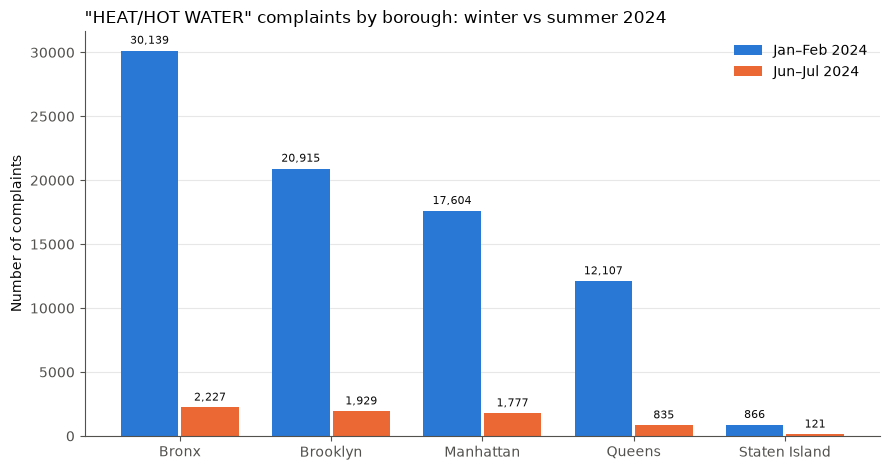

In [9]:
import numpy as np
c = cmp.drop('ALL BOROUGHS')
x = np.arange(len(c)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
b1 = ax.bar(x - w/2 - 0.01, c['Jan-Feb 2024'], w, color=BLUE, label='Jan–Feb 2024')
b2 = ax.bar(x + w/2 + 0.01, c['Jun-Jul 2024'], w, color=ORANGE, label='Jun–Jul 2024')
for b in (b1, b2):
    ax.bar_label(b, labels=[f'{int(v):,}' for v in b.datavalues], padding=3, fontsize=8, color=INK)
ax.set_xticks(x, c.index)
ax.set_title(f'"{top_type}" complaints by borough: winter vs summer 2024', loc='left')
ax.set_ylabel('Number of complaints')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig('top_complaint_jan_feb_vs_jun_jul_2024.png', dpi=120); plt.show()

## Findings

- **HEAT/HOT WATER** is the most abundant complaint type in Jan–Feb 2024 (81,631; 15.6% of all complaints), narrowly ahead of Illegal Parking (79,916).
- In Jun–Jul 2024 it drops to 6,889 complaints (**−91.6%**, ~1,360/day → ~113/day) and falls to **#25**. The drop is −86% to −93% in every borough: it is a seasonal complaint tied to NYC's Oct 1 – May 31 heat season (hot water is required year-round, hence the summer remainder).
- The **Bronx** files the most heat complaints in both periods (37% of the citywide total in winter) despite being smaller than Brooklyn and Queens.
- Summer's top complaints are Illegal Parking, Noise - Residential and Noise - Street/Sidewalk.

Full write-up: `complaint_type_analysis.md`.